# Demo: Controlled Pendulum
## Verification Master Pendulum within System

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

repo_root = Path.cwd().parent.parent
sys.path.insert(0, str(repo_root))
from thesis.plot_setup import set_professional_style
plt = set_professional_style()

sys.path.insert(0, str(repo_root / "examples"))
from examples.update_fmus import get_fmu_paths

**Generate FMUComponents**

In [2]:
from syssimx.components import FMUComponent

demo_dir_path = Path(repo_root / "demos" / "ControlledPendulum")
package_path = Path.cwd() / "MyModels/Modelica/ControlledPendulum/"
fmu_output_dir = Path.cwd() / "MyModels/FMUs/"
fmu_paths = get_fmu_paths(package_path, fmu_output_dir, force_rebuild=False)

All FMUs for package 'ControlledPendulum' already exist. Skipping generation.


In [3]:
ref = FMUComponent(name="ref", fmu_path=fmu_paths["Reference"], group="Input")
sensor_ref = FMUComponent(name="sensor_ref", fmu_path=fmu_paths["AngleEncoder"], group="Sensors")
sensor_state = FMUComponent(
    name="sensor_state", fmu_path=fmu_paths["AngleEncoder"], group="Sensors"
)
drive = FMUComponent(name="drive", fmu_path=fmu_paths["Drive"], group="Actuator")

In [4]:
class PID(FMUComponent):
    """
    FMU-based PID controller component with integrator reset on events.
    """

    def __init__(self, name, group="Controller"):
        fmu_path = Path.cwd() / "MyModels/FMUs" / "PID_Continuous_Euler.fmu"
        super().__init__(name, fmu_path, group)

    def _handle_events_internal(self, event_names, t):
        if "wall_hit" not in event_names:
            return
        self.set_inputs({"resetI": True})
        self.do_step(t, 0)  # Perform a step to apply the resetI input
        self.set_inputs({"resetI": False})


pid = PID(name="pid", group="Control")
pid = PID(name="pid")
pid_paramters = {"k": 10, "Ti": 0.2, "Td": 0.1, "Nd": 10}
parameters = pid.set_parameters(**pid_paramters)

In [5]:
import MyModels.FEM.pendulum_config as config
from MyModels.MasterPendulum.master_pendulum import MasterPendulum

mesh_params = config.MeshParameters()

init_params = config.InitialConditionParameters()
init_params.angular_position_deg = 0  # Initial angle
q0 = np.deg2rad(init_params.angular_position_deg)
init_params.drive_torque = 0  # Nm

mat_params = config.MaterialParameters()
mat_params.E_pendulum = 2.1e11  # Young's modulus for the pendulum
mat_params.nu_pendulum = 0.3    # Poisson's ratio for the pendulum
mat_params.rho_pendulum = 2700  # Density for the pendulum

sim_params = config.SimulationParameters()
sim_params.tau = 0.001
sim_params.t_end = 5
sim_params.with_contact = True
sim_params.use_gravity = True

contact_params = config.ContactParameters()
contact_params.kn = 1e10

anim_params = config.AnimationParameters()
anim_params.animate = True

fem_parameters = {
    'mat_params': mat_params,
    'contact_params': contact_params,
    'init_params': init_params,
    'sim_params': sim_params,
    'anim_params': anim_params,
    'mesh_params': mesh_params,
}

pendulum = MasterPendulum(name="MasterPendulum", initial_mode="FMU")

pendulum.set_parameters(**{"FEM": fem_parameters})

t = 0.0
dt = pendulum.fem.sim_params.tau
t_end = pendulum.fem.sim_params.t_end

**Setup Events and EventConnections in System**

In [6]:
from syssimx.core.base import CoSimComponent
from syssimx.core.events import Event


def wall_contact_indicator(comp: CoSimComponent) -> float:
    theta = comp.get_outputs()["q"]
    threshold = np.deg2rad(0)  # 0 degrees in radians
    return theta - threshold


event = Event(name="wall_hit", source=pendulum.name, direction=-1)

pendulum.add_event_indicator(event.name, wall_contact_indicator, event.direction)

**Define Connections**

In [7]:
from syssimx.system.connection import Connection, EventConnection

c1 = Connection(
    src_comp=ref.name,
    src_port=ref.output_specs["q_ref"].name,
    dst_comp=sensor_ref.name,
    dst_port=sensor_ref.input_specs["q"].name,
)

c2 = Connection(
    src_comp=pendulum.name,
    src_port=pendulum.output_specs["q"].name,
    dst_comp=sensor_state.name,
    dst_port=sensor_state.input_specs["q"].name,
)

c3 = Connection(
    src_comp=sensor_ref.name,
    src_port=sensor_ref.output_specs["U_q"].name,
    dst_comp=pid.name,
    dst_port=pid.input_specs["ref"].name,
)

c4 = Connection(
    src_comp=sensor_state.name,
    src_port=sensor_state.output_specs["U_q"].name,
    dst_comp=pid.name,
    dst_port=pid.input_specs["y"].name,
)

c5 = Connection(
    src_comp=pid.name,
    src_port=pid.output_specs["u"].name,
    dst_comp=drive.name,
    dst_port=drive.input_specs["u_control"].name,
)

c6 = Connection(
    src_comp=drive.name,
    src_port=drive.output_specs["torque"].name,
    dst_comp=pendulum.name,
    dst_port=pendulum.input_specs["torque"].name,
)

c7 = Connection(
    src_comp=pendulum.name,
    src_port=pendulum.output_specs["omega"].name,
    dst_comp=drive.name,
    dst_port=drive.input_specs["omega"].name,
)

event_connection_1 = EventConnection(
    src_comp=pendulum.name,
    src_port="wall_hit",
    dst_comp=pendulum.name,
    dst_port=pendulum.input_specs["omega_invert"].name,
)

event_connection_2 = EventConnection(
    src_comp=pendulum.name,
    src_port="wall_hit",
    dst_comp=pid.name,
    dst_port=pid.input_specs["resetI"].name,
)

connections = [c1, c2, c3, c4, c5, c6, c7]
event_connections = [event_connection_1, event_connection_2]
components = [ref, sensor_ref, sensor_state, pid, drive, pendulum]

**Define System**

In [8]:
from syssimx.system.system import System

system = System(name="Controlled Pendulum System")

for comp in components:
    system.add_component(comp)

for conn in connections:
    system.add_connection(conn)

for event_conn in event_connections:
    system.add_event_connection(event_conn)

system.initialize(t)

LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_SOLVER        | info    | CVODE maximum integration order CV_ITER_NEWTON
LOG_SOLVER        | info    | CVODE use equidistant time grid YES
LOG_SOLVER        | info    | CVODE Using relative error tolerance 1.000000e-06
LOG_SOLVER        | info    | CVODE Using dense internal linear solver SUNLinSol_Dense.
LOG_SOLVER        | info    | CVODE Use internal dense numeric jacobian method.
LOG_SOLVER        | info    | CVODE uses internal root finding method NO
LOG_SOLVER        | info    | CVODE maximum absolut step size 0
LOG_SOLVER        | info    | CVODE initial step size is set automatically
LOG_SOLVER        | info    | CVODE maximum integration order 5
LOG_SOLVER        | info    | CVODE maximum number of nonlinear convergence failures permitted during one step 10
LOG_SOLVER        | info    | CVODE BDF stability limit detection algorithm OFF
MasterPendulum: Detected direct_feedthrough={'q': set(), 'omega': set(),

In [9]:
print("Execution Order (generations):")
for gen in system.execution_order:
    print(gen)

Execution Order (generations):
['MasterPendulum', 'ref']
['sensor_ref', 'sensor_state']
['pid']
['drive']


**Create System Graph**

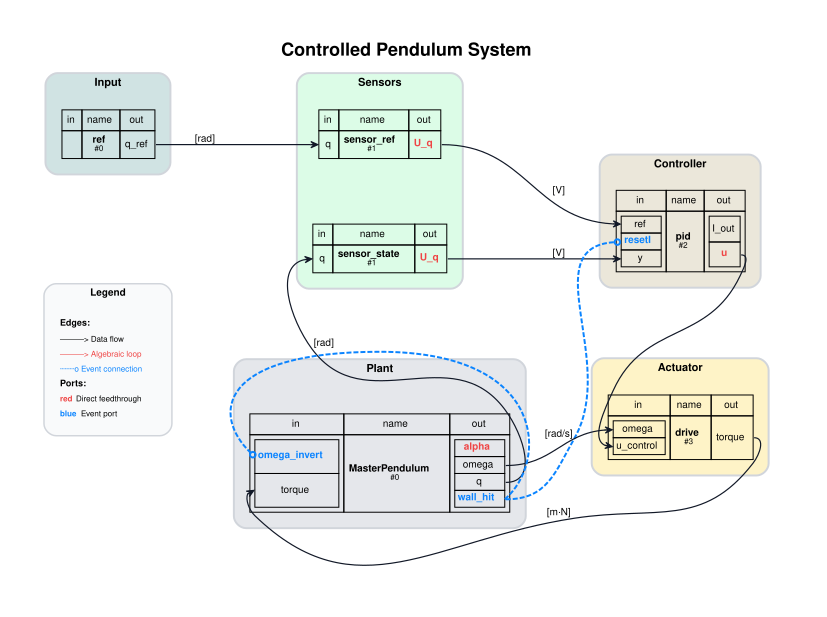

In [10]:
from syssimx.viz.system_graph_visualizer import SystemGraphVisualizer

visualizer = SystemGraphVisualizer(system)
visualizer.visualize()

**Setup Simulation Monitor**

In [11]:
pendulum.setup_monitoring()
pendulum.display_monitoring()
pendulum._update_output_states(t=0)

HTML(value="<h3 style='color:#1565c0; font-family:Inter, sans-serif; margin:15px 0 20px 0; text-align:center; …

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

In [12]:
t_start = 0.0
t_end = 5.0
dt = 0.001  # Macro step size

system.run(t0=t_start, tf=t_end, dt=dt)

KeyboardInterrupt: 

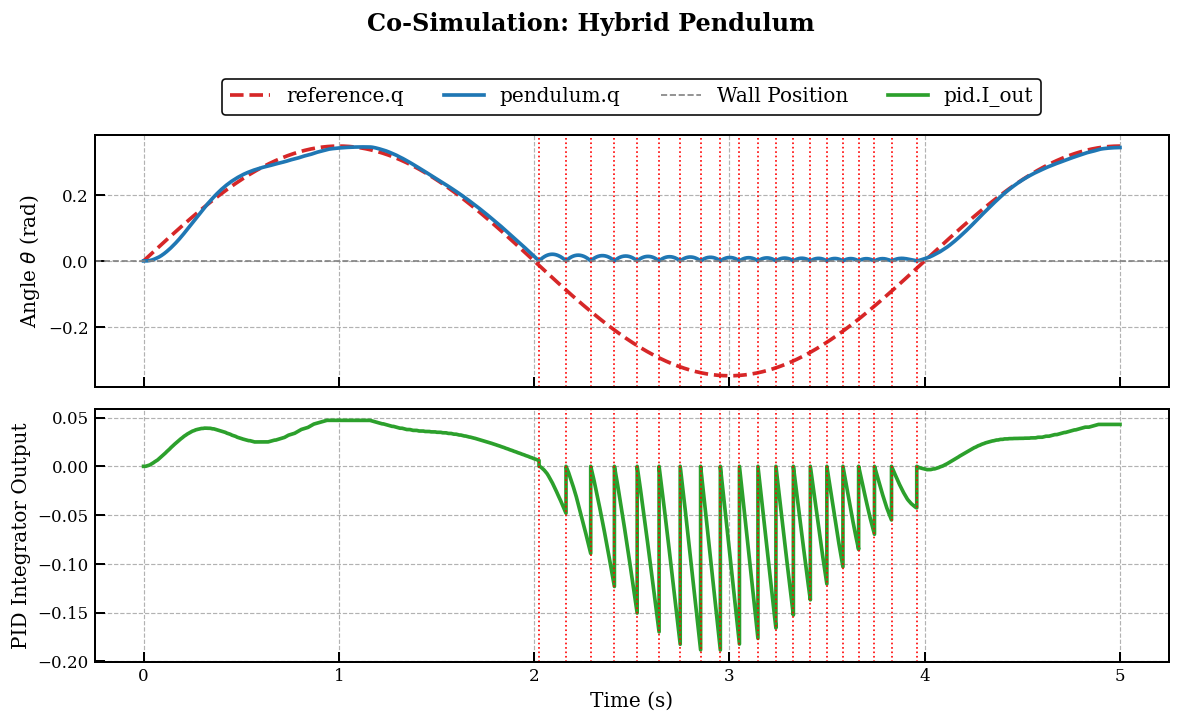

In [ ]:
history = system.get_history()

ref_history = history["ref"]
pid_history = history["pid"]
pendulum_history = history["MasterPendulum"]
event_history = history["Events"]

event_times = event_history[("MasterPendulum", "wall_hit")]

t_ref, data = ref_history
q_ref = data["q_ref"]
t_pendulum, data = pendulum_history
q_pendulum = data["q"]
t_pid, data = pid_history
i_out = data["I_out"]

event_times = [et.t for et in event_times]

fig, axs = plt.subplots(ncols=1, nrows=2, sharex=True)
fig.set_size_inches(10, 6)

fig.suptitle(r"Co-Simulation: Hybrid Pendulum", fontweight="bold", y=1)

(s1,) = axs[0].plot(t_ref, q_ref, label="reference.q", color="tab:red", linestyle="--")
(s2,) = axs[0].plot(t_pendulum, q_pendulum, label="pendulum.q", color="tab:blue")
s3 = axs[0].axhline(0, label="Wall Position", color="gray", linestyle="--", linewidth=1)
axs[0].set_ylabel(r"Angle $\theta$ (rad)")
axs[0].grid()

(s4,) = axs[1].plot(t_pid, i_out, label="pid.I_out", color="tab:green")
axs[1].set_ylabel("PID Integrator Output")
axs[1].set_xlabel("Time (s)")
axs[1].grid()

handles = [s1, s2, s3, s4]
axs[0].legend(handles=handles, loc="center", bbox_to_anchor=(0.5, 1.15), ncols=4)

for t_event in event_times:
    axs[0].axvline(t_event, color="red", linestyle=":", linewidth=1)
    axs[1].axvline(t_event, color="red", linestyle=":", linewidth=1)

# plt.savefig('../figures/Hybrid/test_6_hybrid_pendulum.svg')
plt.tight_layout()
plt.show()

In [ ]:
res_file = Path.cwd() / "results/hybrid" / "controlled_pendulum_hybrid_wall.csv"
system.history.save_csv(res_file)

Results saved to: /home/flo/code/SystemSimulation/demos/ControlledPendulum/results/hybrid/controlled_pendulum_hybrid_wall.csv


In [ ]:
ref_hist = ref.get_history()
t_vals_ref = ref_hist["q_ref"]["time"]
q_vals_ref = ref_hist["q_ref"]["values"]

if isinstance(pendulum, MasterPendulum):
    res_eqb = pendulum.models["EQB"].get_history()
    res_fem = pendulum.models["FEM"].get_history()
    res_os = pendulum.models["OpenSim"].get_history()

    t_vals_eqb = res_eqb["q"]["time"]
    q_vals_eqb = res_eqb["q"]["values"]
    omega_vals_eqb = res_eqb["omega"]["values"]
    alpha_vals_eqb = res_eqb["alpha"]["values"]

    t_vals_fem = res_fem["q"]["time"]
    q_vals_fem = res_fem["q"]["values"]
    omega_vals_fem = res_fem["omega"]["values"]
    alpha_vals_fem = res_fem["alpha"]["values"]

    t_vals_os = res_os["q"]["time"]
    q_vals_os = res_os["q"]["values"]
    omega_vals_os = res_os["omega"]["values"]
    alpha_vals_os = res_os["alpha"]["values"]

if isinstance(pendulum, FMUComponent):
    pendulum_hist = pendulum.get_history()
    t_vals_eqb = pendulum_hist["q"]["time"]
    q_vals_eqb = pendulum_hist["q"]["values"]
    omega_vals_eqb = pendulum_hist["omega"]["values"]
    alpha_vals_eqb = pendulum_hist["alpha"]["values"]

# Drive torque
drive_hist = drive.get_history()
t_drive = drive_hist["torque"]["time"]
torque_drive_vals = drive_hist["torque"]["values"]

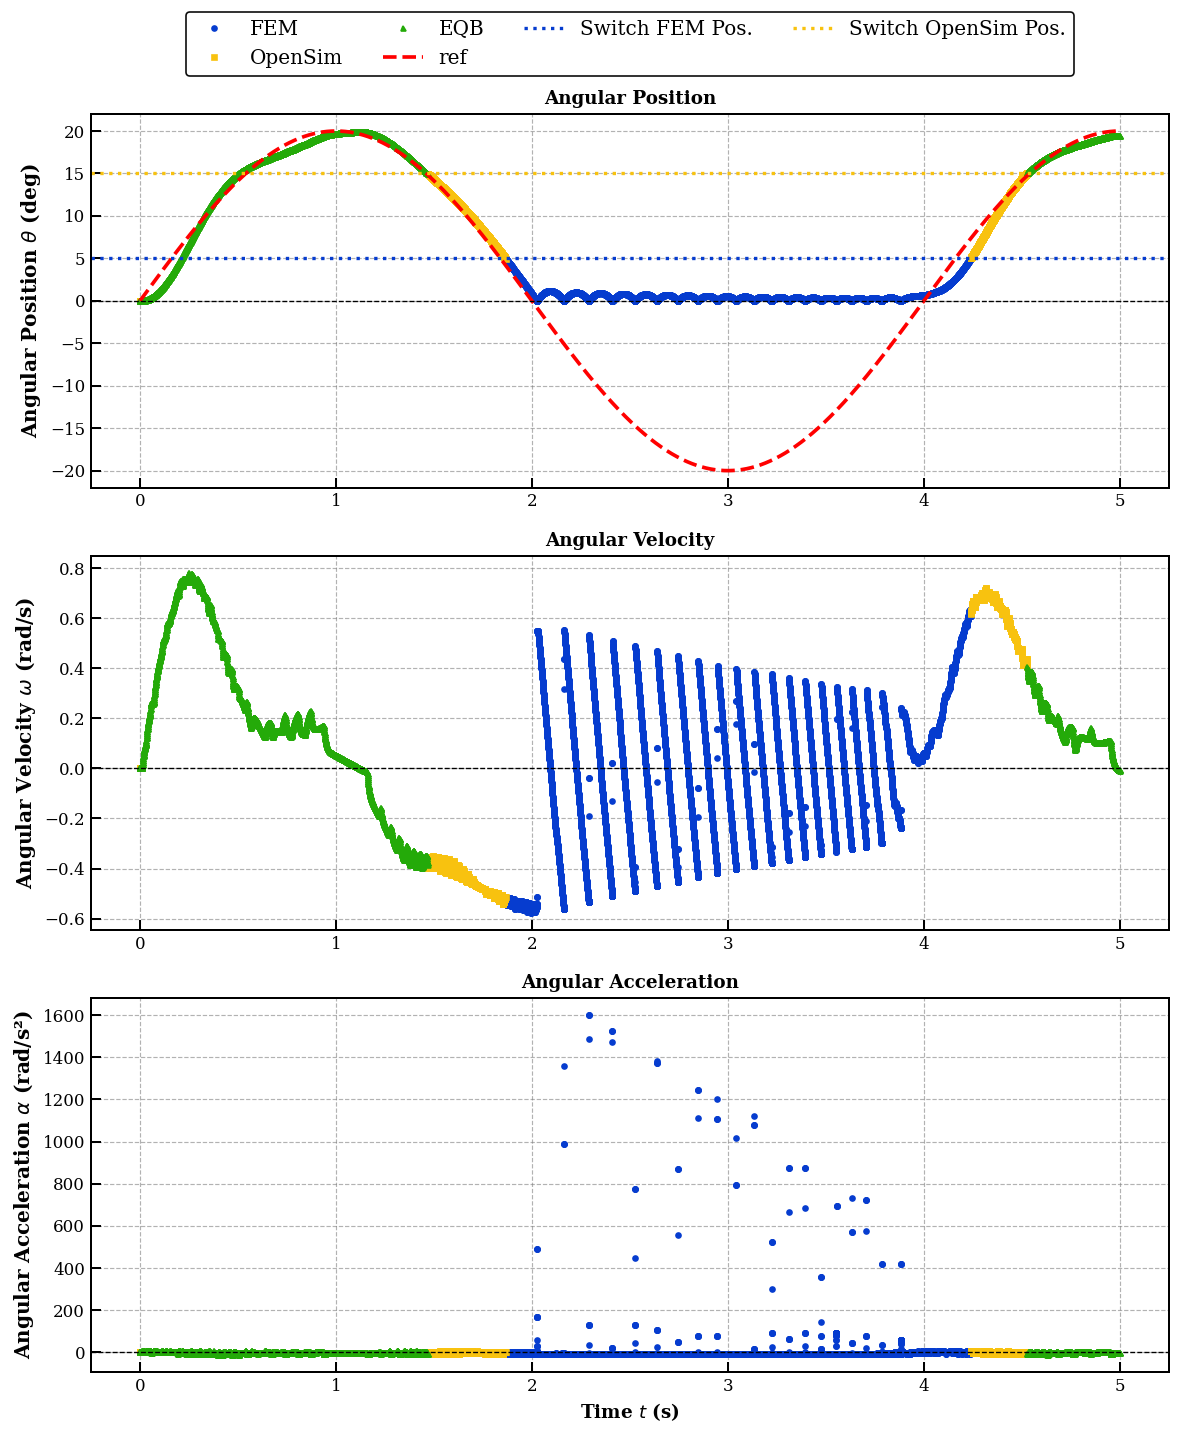

In [ ]:
marker_size = 3
fem_style = {
    "color": "#063ccf",
    "linestyle": "None",
    "marker": "o",
    "markersize": marker_size,
    "linewidth": 3.5,
}  # Deep blue
opensim_style = {
    "color": "#f8c20f",
    "linestyle": "None",
    "marker": "s",
    "markersize": marker_size,
    "linewidth": 3.5,
}  # Green
eqb_style = {
    "color": "#24aa09",
    "linestyle": "None",
    "marker": "^",
    "markersize": marker_size,
    "linewidth": 3.5,
}  # Purple
fontdict = {"fontsize": 11, "fontweight": "bold"}

plt.figure(figsize=(10, 12))

plt.subplot(3, 1, 1).set_title("Angular Position", **fontdict)
plt.plot(t_vals_fem, np.rad2deg(q_vals_fem), label="FEM", **fem_style)
plt.plot(t_vals_os, np.rad2deg(q_vals_os), label="OpenSim", **opensim_style)
plt.plot(t_vals_eqb, np.rad2deg(q_vals_eqb), label="EQB", **eqb_style)
plt.plot(t_vals_ref, np.rad2deg(q_vals_ref), label="ref", color="red", linestyle="--")
plt.axhline(5, color=fem_style["color"], linestyle=":", label="Switch FEM Pos.", linewidth=2)
plt.axhline(
    15, color=opensim_style["color"], linestyle=":", label="Switch OpenSim Pos.", linewidth=2
)
plt.axhline(0, color="k", linestyle="--", linewidth=0.8)
plt.ylabel(r"Angular Position $\theta$ (deg)", fontweight="bold")
plt.grid(which="both")
plt.legend(loc="upper center", bbox_to_anchor=(0.5, 1.3), ncol=4)


plt.subplot(3, 1, 2).set_title("Angular Velocity", **fontdict)
plt.plot(t_vals_fem, omega_vals_fem, label="FEM", **fem_style)
plt.plot(t_vals_os, omega_vals_os, label="OpenSim", **opensim_style)
plt.plot(t_vals_eqb, omega_vals_eqb, label="EQB", **eqb_style)
plt.axhline(0, color="k", linestyle="--", linewidth=0.8)
plt.ylabel(r"Angular Velocity $\omega$ (rad/s)", fontweight="bold")
plt.grid(which="both")

plt.subplot(3, 1, 3).set_title("Angular Acceleration", **fontdict)
plt.plot(t_vals_fem[:-1], alpha_vals_fem[:-1], label="FEM", **fem_style)
plt.plot(t_vals_os, alpha_vals_os, label="OpenSim", **opensim_style)
plt.plot(t_vals_eqb, alpha_vals_eqb, label="EQB", **eqb_style)
plt.axhline(0, color="k", linestyle="--", linewidth=0.8)
plt.ylabel(r"Angular Acceleration $\alpha$ (rad/s²)", fontweight="bold")
plt.grid(which="both")

plt.xlabel("Time $t$ (s)", **fontdict)
plt.tight_layout()
# plt.savefig("figures/System_MasterPendulum.svg")
plt.show()

In [ ]:
import pandas as pd
import tabulate

# Create DataFrame for better handling
sync_data = []

for event in pendulum.sync_events:
    # Extract values
    time = event["time"]
    from_mode = event["from_mode"]
    to_mode = event["to_mode"]

    ret = event["retrieved"]
    new = event["now"]

    # Helper to extract magnitude
    def get_val(x):
        if hasattr(x, "magnitude"):
            return x.magnitude
        return float(x) if hasattr(x, "__float__") else x

    sync_data.append(
        {
            "Time (s)": f"{time:.4f}",
            "Transition": f"{from_mode} → {to_mode}",
            "θ_ret (°)": f"{np.rad2deg(get_val(ret['q']['value'])):.2f}",
            "ω_ret": f"{get_val(ret['omega']['value']):.3f}",
            "α_ret": f"{get_val(ret['alpha']['value']):.1f}",
            "τ_ret": f"{get_val(ret['torque']['value']):.2f}",
            "θ_new (°)": f"{np.rad2deg(get_val(new['q']['value'])):.2f}",
            "ω_new": f"{get_val(new['omega']['value']):.3f}",
            "α_new": f"{get_val(new['alpha']['value']):.1f}",
            "τ_new": f"{get_val(new['torque']['value']):.2f}",
        }
    )

df = pd.DataFrame(sync_data)

print("\n" + "=" * 140)
print(" " * 50 + "MODE SYNCHRONIZATION EVENTS")
print("=" * 140)
print(tabulate.tabulate(df, headers="keys", tablefmt="grid", showindex=False))
print("=" * 140)
print(f"Total mode switches: {len(sync_data)}")
print("=" * 140 + "\n")


                                                  MODE SYNCHRONIZATION EVENTS
+------------+---------------+-------------+---------+---------+---------+-------------+---------+---------+---------+
|   Time (s) | Transition    |   θ_ret (°) |   ω_ret |   α_ret |   τ_ret |   θ_new (°) |   ω_new |   α_new |   τ_new |
+============+===============+=============+=========+=========+=========+=============+=========+=========+=========+
|      1.468 | EQB → OpenSim |       14.99 |  -0.378 |    -6.8 |  -64.67 |       14.99 |  -0.378 |    -6.8 |  -64.67 |
+------------+---------------+-------------+---------+---------+---------+-------------+---------+---------+---------+
|      1.865 | OpenSim → FEM |        4.99 |  -0.515 |     1.1 |   41.55 |        4.99 |  -0.515 |     1.1 |   41.55 |
+------------+---------------+-------------+---------+---------+---------+-------------+---------+---------+---------+
|      4.24  | FEM → OpenSim |        5.03 |   0.609 |     3.8 |  133.32 |        5.03 |

-------------------------------------------------------------

## Monolithic Modelica Reference Solution

In [ ]:
from OMPython import ModelicaSystem

In [ ]:
root = Path.cwd()
pkg_path = root / "MyModels/Modelica/ControlledPendulum/package.mo"
model_name = "ControlledPendulum.Demo_DrivenWithWallDiscrete"

model = ModelicaSystem(str(pkg_path), model_name)

solution_names = ("time", "pid.I_out", "reference.q_ref", "pendulum.q", "pendulum.contact")

startTime = 0.0
stopTime = 5.0
stepSize = 0.0001

model.setParameters("useReset=true")
model.buildModel()
model.setSimulationOptions(
    [f"startTime={startTime}", f"stopTime={stopTime}", f"stepSize={stepSize}"]
)
model.simulate()
res = {name: model.getSolutions(name).flatten() for name in solution_names}


Notification: Automatically loaded package Complex 4.0.0 due to uses annotation from Modelica.
Notification: Automatically loaded package ModelicaServices 4.0.0 due to uses annotation from Modelica.
Notification: Automatically loaded package Modelica 4.0.0 due to usage.


LOG_SUCCESS       | info    | The initialization finished successfully without homotopy method.
LOG_SUCCESS       | info    | The simulation finished successfully.


In [ ]:
marker_size = 1
fem_style = {
    "color": "#063ccf",
    "linestyle": "None",
    "marker": "o",
    "markersize": marker_size,
    "linewidth": 1,
}  # Deep blue
opensim_style = {
    "color": "#f8c20f",
    "linestyle": "None",
    "marker": "o",
    "markersize": marker_size,
    "linewidth": 1,
}  # Green
eqb_style = {
    "color": "#24aa09",
    "linestyle": "None",
    "marker": "o",
    "markersize": marker_size,
    "linewidth": 1,
}  # Purple

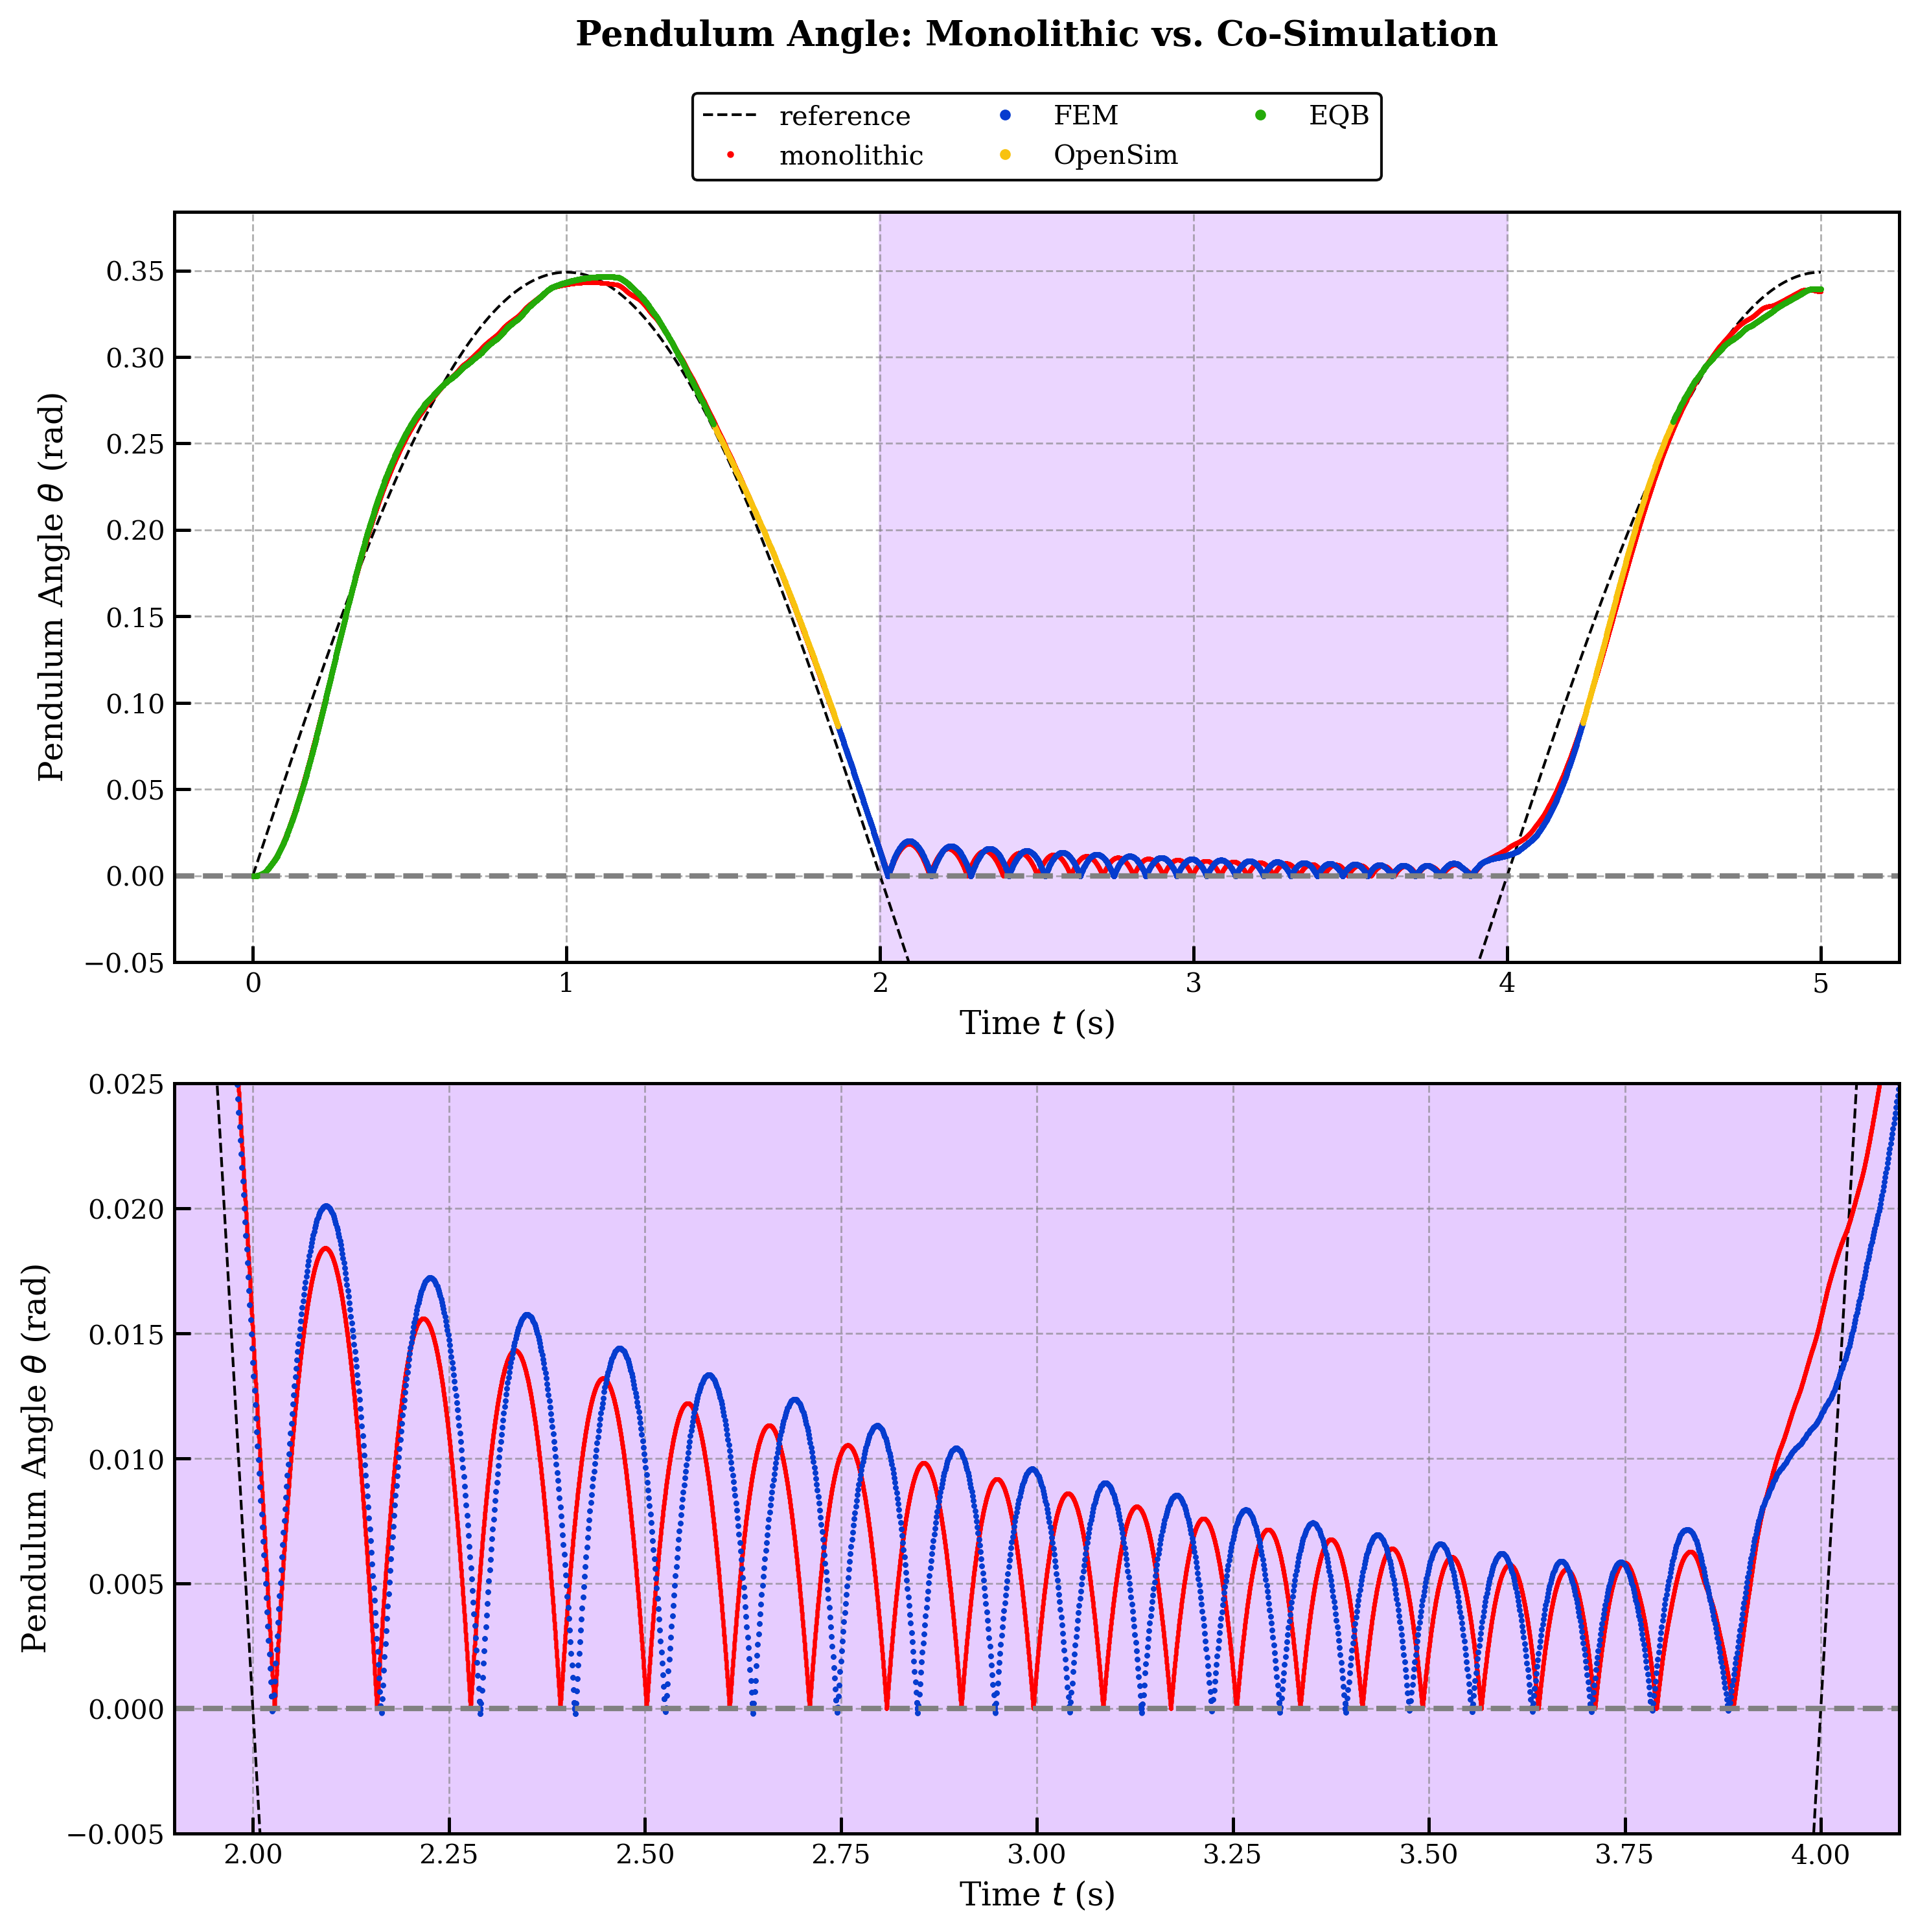

In [ ]:
plt.figure(figsize=(10, 10))

zoom1_color = (0.9, 0.8, 1.0)  # Purple for first zoom region
zoom2_color = (1.0, 0.9, 0.8)  # Orange for second zoom region

plt.subplot(2, 1, 1)
plt.title(r"Pendulum Angle: Monolithic vs. Co-Simulation", fontweight="bold", y=1.2)
plt.plot(t_ref, q_ref, label="reference", color="black", linestyle="--", linewidth=1)
plt.plot(
    res["time"],
    res["pendulum.q"],
    label="monolithic",
    color="red",
    marker=".",
    linestyle="None",
    markersize=1,
)
plt.plot(t_vals_fem, q_vals_fem, label="FEM", **fem_style)
plt.plot(t_vals_os, q_vals_os, label="OpenSim", **opensim_style)
plt.plot(t_vals_eqb, q_vals_eqb, label="EQB", **eqb_style)
plt.axhline(0, color="gray", linestyle="--", linewidth=2)
plt.ylabel(r"Pendulum Angle $\theta$ (rad)")
plt.xlabel(r"Time $t$ (s)")
plt.ylim(-0.05)
plt.grid()
plt.legend(loc="center", bbox_to_anchor=(0.5, 1.1), ncol=3, markerscale=3)

plt.axvspan(2, 4, color=zoom1_color, alpha=0.8)

plt.subplot(2, 1, 2)
plt.plot(t_ref, q_ref, label="reference", color="black", linestyle="--", linewidth=1)
plt.plot(
    res["time"],
    res["pendulum.q"],
    label="monolithic",
    color="red",
    marker=".",
    linestyle="None",
    markersize=1,
)
plt.plot(t_vals_fem, q_vals_fem, label="FEM", **fem_style)
plt.plot(t_vals_os, q_vals_os, label="OpenSim", **opensim_style)
plt.plot(t_vals_eqb, q_vals_eqb, label="EQB", **eqb_style)
plt.axhline(0, color="gray", linestyle="--", linewidth=2)
plt.ylabel(r"Pendulum Angle $\theta$ (rad)")
plt.xlabel(r"Time $t$ (s)")
plt.xlim(1.9, 4.1)
plt.ylim(-0.005, 0.025)
plt.grid()
plt.gca().set_facecolor((0.9, 0.8, 1.0))

plt.tight_layout()
plt.savefig("figures/verification_hybrid_master_pendulum_1.svg")
plt.show()

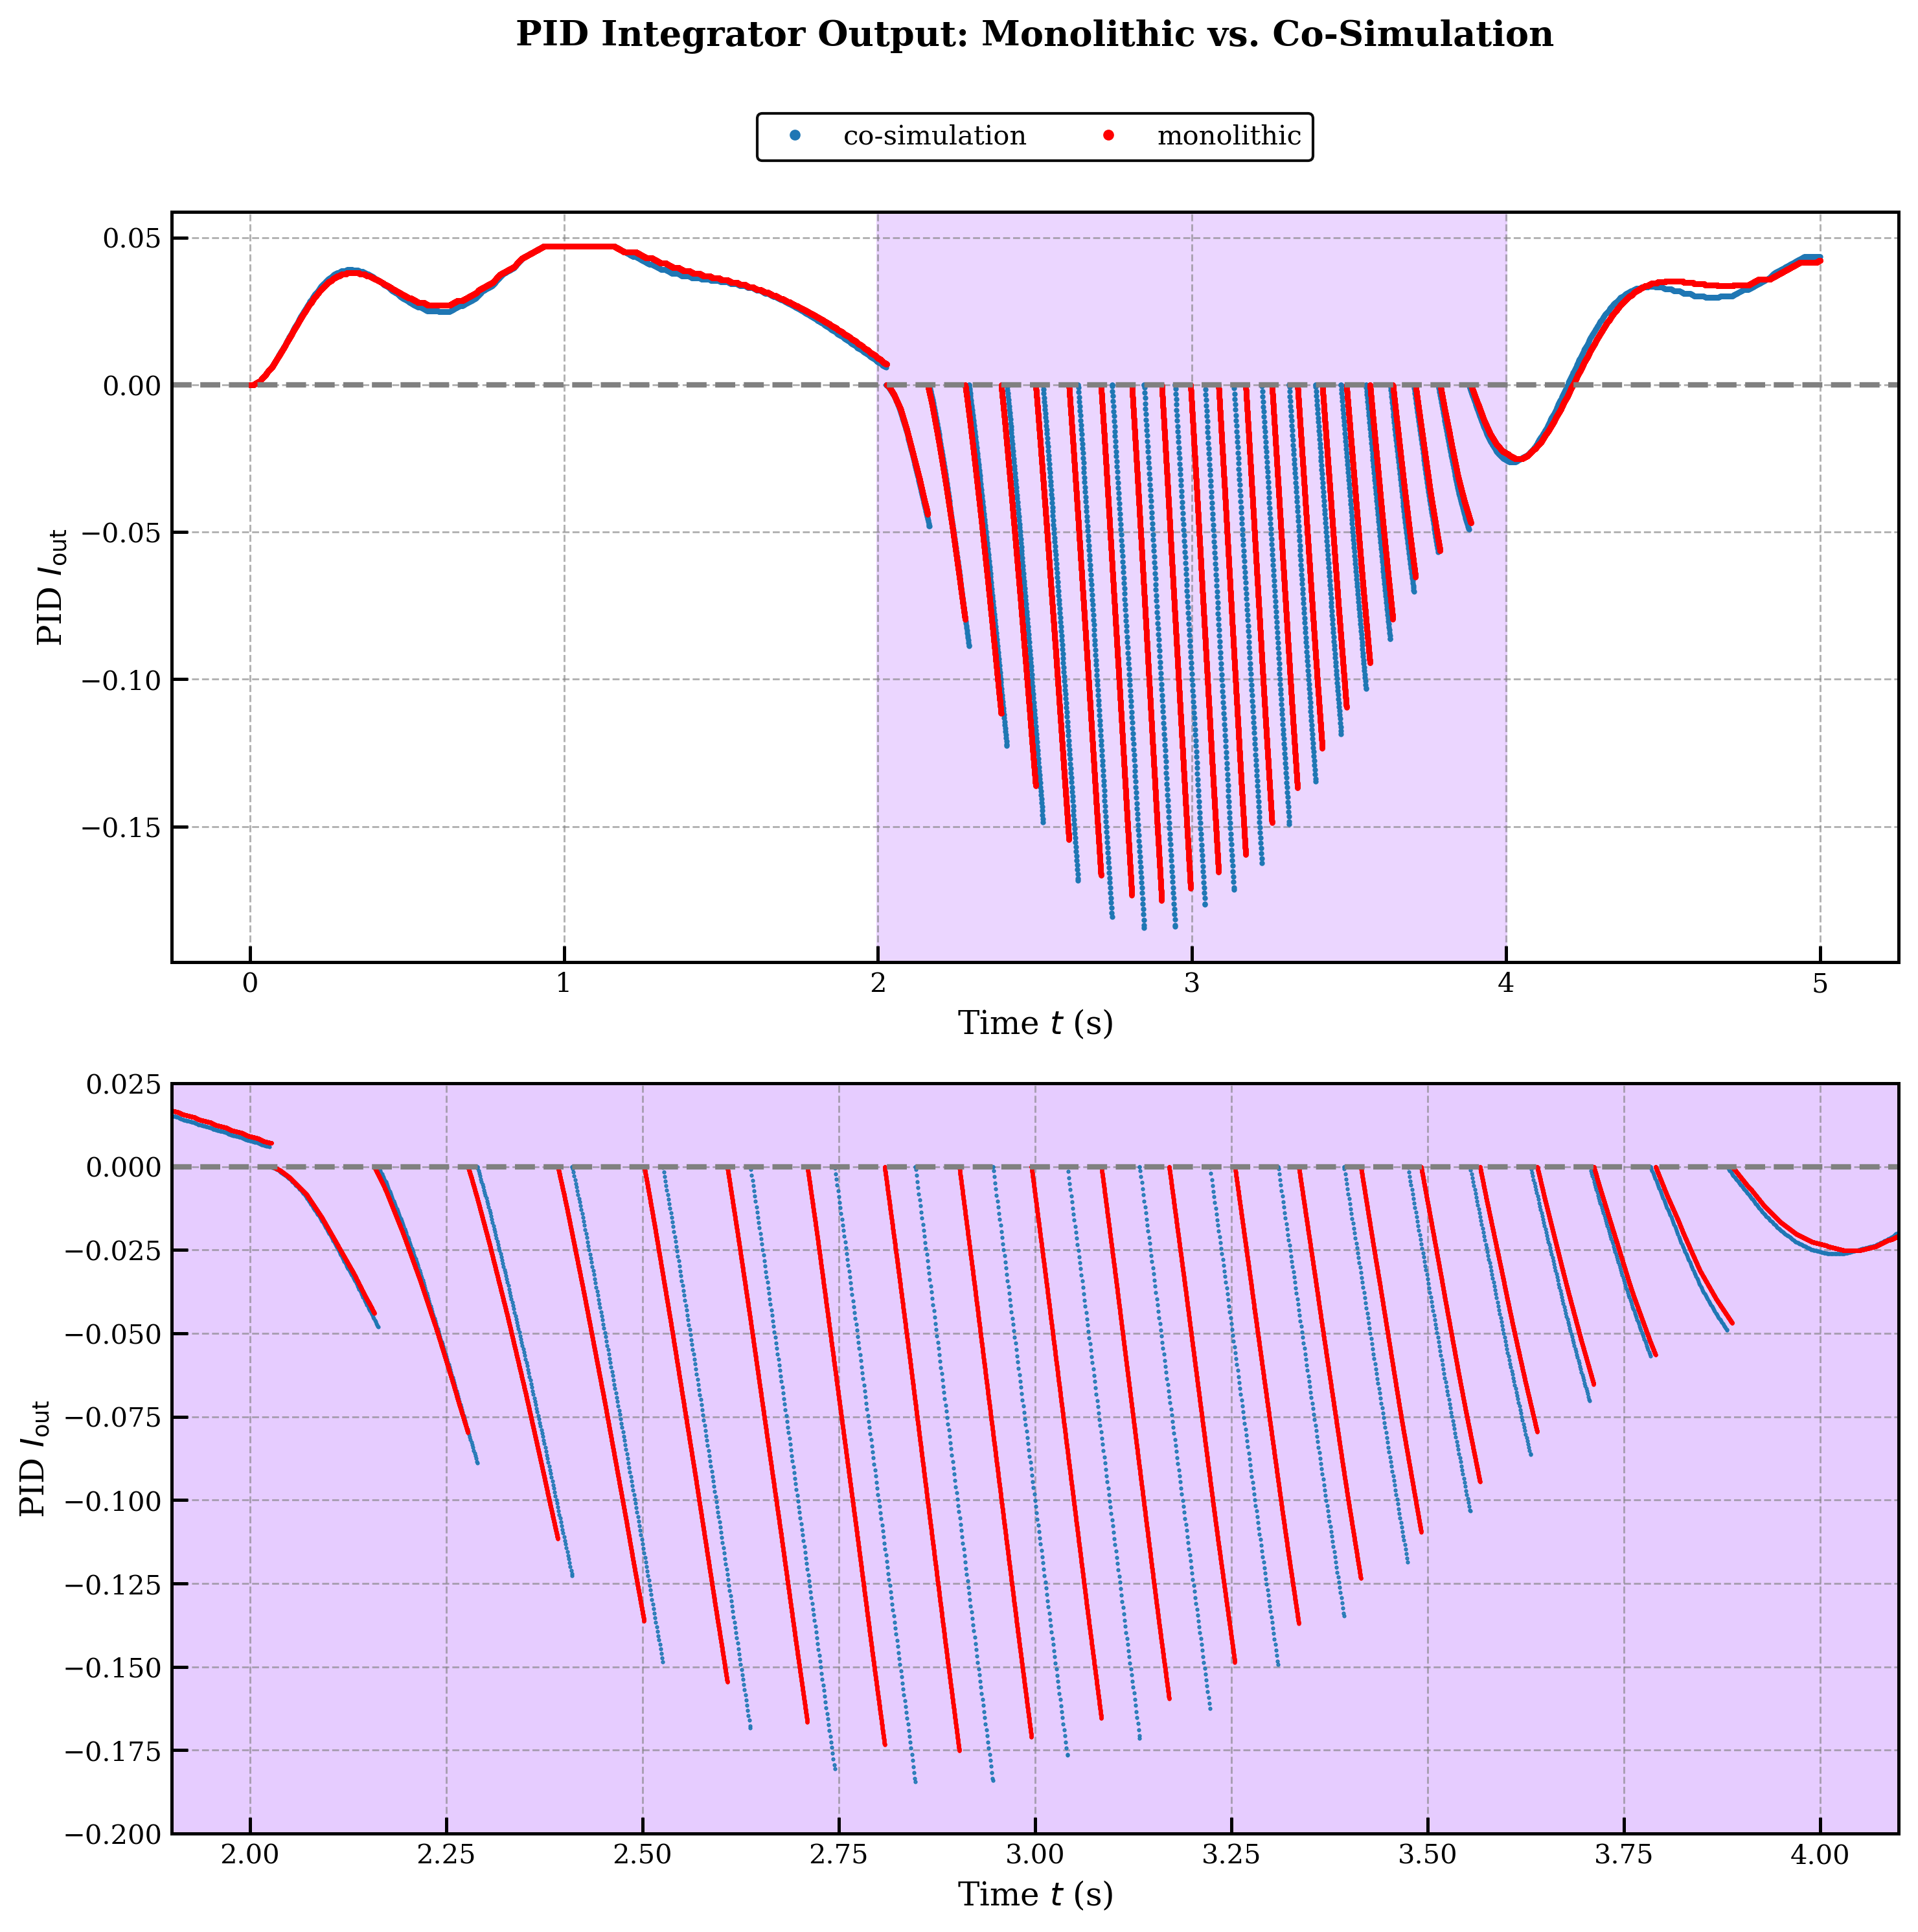

In [ ]:
plt.figure(figsize=(10, 10))

zoom1_color = (0.9, 0.8, 1.0)  # Purple for first zoom region
zoom2_color = (1.0, 0.9, 0.8)  # Orange for second zoom region

plt.subplot(2, 1, 1)
plt.title(r"PID Integrator Output: Monolithic vs. Co-Simulation", fontweight="bold", y=1.2)
plt.plot(
    t_pid,
    i_out,
    label="co-simulation",
    color="tab:blue",
    marker="o",
    linestyle="None",
    markersize=1,
)
plt.plot(
    res["time"],
    res["pid.I_out"],
    label="monolithic",
    color="red",
    marker="o",
    linestyle="None",
    markersize=1,
)
plt.axhline(0, color="gray", linestyle="--", linewidth=2)
plt.ylabel(r"PID $I_{\text{out}}$")
plt.xlabel(r"Time $t$ (s)")
plt.grid()
plt.legend(loc="center", bbox_to_anchor=(0.5, 1.1), ncol=2, markerscale=3)

plt.axvspan(2, 4, color=zoom1_color, alpha=0.8)

plt.subplot(2, 1, 2)
plt.plot(
    t_pid,
    i_out,
    label="co-simulation",
    color="tab:blue",
    marker=".",
    linestyle="None",
    markersize=1,
)
plt.plot(
    res["time"],
    res["pid.I_out"],
    label="monolithic",
    color="red",
    marker=".",
    linestyle="None",
    markersize=1,
)
plt.axhline(0, color="gray", linestyle="--", linewidth=2)
plt.ylabel(r"PID $I_{\text{out}}$")
plt.xlabel(r"Time $t$ (s)")
plt.xlim(1.9, 4.1)
plt.ylim(-0.2, 0.025)
plt.grid()
plt.gca().set_facecolor((0.9, 0.8, 1.0))

plt.tight_layout()
plt.savefig("figures/verification_hybrid_master_pendulum_2.svg")
plt.show()